# Dice between channels — virus vs CD31 vessel segmentation

This notebook takes the **paper-1 style** approach to comparing the two channels:
segment vessels in *both* the virus and the CD31 channel, then score how much the
two masks overlap. It reuses the merged analysis code in `scripts/` so the numbers
match the command-line tools exactly.

Read this alongside **`enrichment_metrics.ipynb`**. For the *specificity* question
("is the virus on the vasculature?") enrichment is the sounder measure — even with
the tuned virus cut below, a segmentation of the virus channel cannot fully trace
the CD31 network, because much of the virus is genuinely non-vascular.

## The pipeline — a tuned cut per channel

Each channel is segmented with a graded Jerman filter (self-normalise → Jerman at
`REFERENCE` → wide-gap hysteresis → clean-up), but the two channels get **different
thresholds on purpose**:

- **CD31** is stained vasculature, so a vessel-like cut (`CD31_LOW`/`CD31_HIGH` =
  0.03/0.09, graded Jerman at `REFERENCE` = 2.0) traces the network directly.
- the **virus** channel is dominated by non-vascular neuronal expression that is
  structurally vessel-like. A **stricter** cut (`VIRUS_LOW`/`VIRUS_HIGH` =
  0.06/0.17) keeps mostly the brighter vesselness responses — the genuinely
  vessel-associated virus — and drops much of the dimmer neuronal ridge signal. On
  a test section this raised specificity against CD31 from ~0.5 (at CD31's own cut)
  to ~0.6, without inventing vessels.

This replaces an earlier "same filter on both channels so it cancels" idea. That
only *looked* clean because both masks over-segmented to ~40% of the tissue and
overlapped trivially, **inflating Dice**; the tuned masks are vessel-like and the
agreement they report is real (and lower). Even so the virus mask cannot fully
match CD31 — for the specificity question use enrichment (next notebook), which
never segments the virus.

## The metrics  (A = virus mask, B = CD31 mask)

| metric | formula | reads as |
| --- | --- | --- |
| **Dice** | $2\,\lvert A\cap B\rvert / (\lvert A\rvert+\lvert B\rvert)$ | symmetric overlap — the headline "agreement" |
| **Jaccard (IoU)** | $\lvert A\cap B\rvert / \lvert A\cup B\rvert$ | same idea, harsher (Dice ≥ Jaccard always) |
| **Specificity** = precision(virus, CD31) | $\lvert A\cap B\rvert / \lvert A\rvert$ | fraction of the virus vessel mask on a real vessel |
| **Coverage** = recall(virus, CD31) | $\lvert A\cap B\rvert / \lvert B\rvert$ | fraction of the vasculature the virus mask reaches |

Specificity and coverage are **asymmetric** and trade off as the virus threshold
moves (stricter → higher specificity, lower coverage) — so read the pair, not Dice
alone. To retune, edit `VIRUS_LOW`/`VIRUS_HIGH` in `scripts/dice_between_channels.py`.

In [1]:
# Bootstrap: walk up to the repo root (the folder with pyproject.toml) and put it
# and scripts/ on sys.path, so this notebook runs from a plain clone with no
# install step -- the same pattern the archive notebooks use.
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for _p in (str(_root), str(_root / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)

from analyse_spinal_cord import NAME, REGION_NAME, curated_paths
from dice_between_channels import (CD31_HIGH, CD31_LOW, VIRUS_HIGH, VIRUS_LOW,
                                   channel_masks, score_section)
from vessel_utils import metrics
from visualize_sections import VIS_Q, _clip, top_q_mask
from zoom_crops import CROP_PX, CROP_UM, _add_scalebar, _crop_slice
from scipy.ndimage import uniform_filter

# Ensure figures render inline. Some imported analysis modules (visualize_sections,
# zoom_crops) set matplotlib to the non-interactive Agg backend on import, which
# would otherwise silence plt.show(); re-assert inline here, after the imports.
%matplotlib inline

print(f"CD31 thresholds {CD31_LOW}/{CD31_HIGH}   virus thresholds {VIRUS_LOW}/{VIRUS_HIGH}")

# Interactive default is a small pilot (both reporters, every region, one slice
# each). Flip to run every section -- slower, because each section is segmented
# twice (once per channel).
RUN_FULL = False

CD31 thresholds 0.03/0.09   virus thresholds 0.06/0.17


In [2]:
paths = curated_paths() if RUN_FULL else curated_paths(pilot_mice=2, slices_per_region=1)
print(f"{len(paths)} sections ({'full dataset' if RUN_FULL else 'pilot'})")

10 sections (pilot)


In [3]:
records = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    try:
        result = score_section(path)
    except Exception as error:                       # empty mask, wrong channel count, ...
        print(f"skip {path.name}: {error}")
        continue
    records.append(dict(figure=figure, reporter=reporter, mouse=mouse,
                        region=region, slice=slice_id or "", **result))

df = pd.DataFrame(records)
df[["figure", "reporter", "mouse", "region", "slice",
    "dice", "jaccard", "specificity", "coverage"]].round(3)

,figure,reporter,mouse,region,slice,dice,jaccard,specificity,coverage
0,Fig 1,SYFP2,M131,C,1,0.407,0.255,0.643,0.298
1,Fig 1,SYFP2,M131,L,11,0.291,0.171,0.542,0.199
2,Fig 1,SYFP2,M131,T,10,0.320,0.191,0.534,0.229
3,Fig 1,SYFP2,M132,C,1,0.525,0.356,0.803,0.390
4,Fig 1,SYFP2,M132,L,11,0.325,0.194,0.539,0.233
5,Fig 1,SYFP2,M132,T,6,0.306,0.181,0.544,0.213
6,Fig 2a,tdT,M63,C,10,0.462,0.300,0.628,0.365
7,Fig 2a,tdT,M63,L,3,0.542,0.372,0.669,0.456
8,Fig 2a,tdT,M63,T,1,0.452,0.292,0.473,0.433
9,Fig 2b,tdT,M87,TL,5,0.286,0.167,0.567,0.191


## Aggregation

Three slices are three views of one animal, so slices are averaged **within
mouse × region** before mice are combined, and figures are kept separate (Fig 1
SYFP2 and Fig 2 tdT are different constructs — pooling would confound
reporter/construct with region).

In [4]:
per_mouse = (df.groupby(["figure", "reporter", "mouse", "region"])
               [["dice", "specificity", "coverage"]].mean().reset_index())
summary = (per_mouse.groupby(["figure", "reporter", "region"])
                     [["dice", "specificity", "coverage"]]
                     .mean().round(3))
summary

dice  specificity  coverage
figure reporter region                              
Fig 1  SYFP2    C       0.466        0.723     0.344
                L       0.308        0.541     0.216
                T       0.313        0.539     0.221
Fig 2a tdT      C       0.462        0.628     0.365
                L       0.542        0.669     0.456
                T       0.452        0.473     0.433
Fig 2b tdT      TL      0.286        0.567     0.191

## Visual check — the agreement map for one section

White = both masks agree (true overlap), **green** = virus-only (off a CD31
vessel), **magenta** = CD31-only (a vessel the virus missed). A lot of green is
low specificity; a lot of magenta is low coverage.

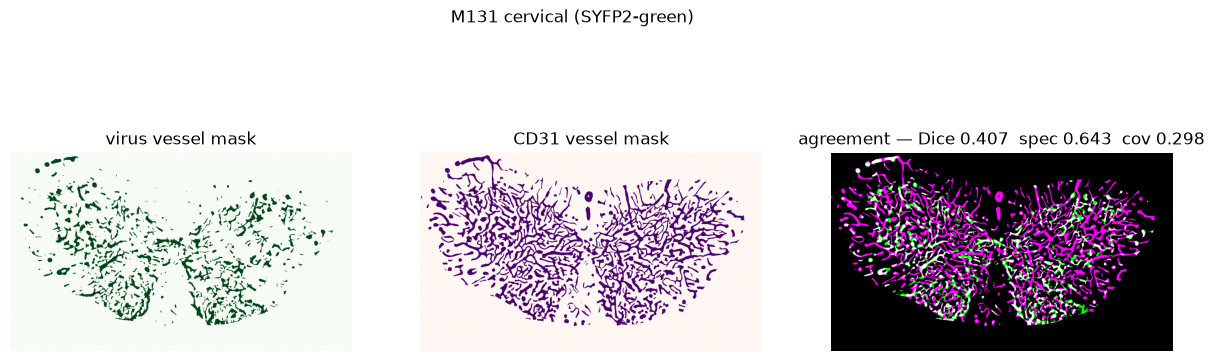

In [5]:
path = paths[0]
virus, cd31, tissue, mask_virus, mask_cd31 = channel_masks(path)

d = np.s_[::2, ::2]
mv, mc = mask_virus[d], mask_cd31[d]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]        # both
agree[mv & ~mc] = [0, 1, 0]       # virus only  -> off-vessel
agree[~mv & mc] = [1, 0, 1]       # CD31 only   -> missed vessel

figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(mv, cmap="Greens");  ax[0].set_title("virus vessel mask")
ax[1].imshow(mc, cmap="RdPu");    ax[1].set_title("CD31 vessel mask")
ax[2].imshow(agree)
ax[2].set_title(f"agreement — Dice {metrics.dice(mask_virus, mask_cd31):.3f}  "
                f"spec {metrics.precision(mask_virus, mask_cd31):.3f}  "
                f"cov {metrics.recall(mask_virus, mask_cd31):.3f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} ({reporter})")
plt.show()

## Segmentation across sections (whole section)

The other visual cells zoom into one section; this shows the CD31 (magenta) and
virus (green) vessel masks and their agreement (white = both, green = virus
off-vessel, magenta = a missed vessel) across several sections — so the Dice /
specificity in the table can be tied to what the masks look like.

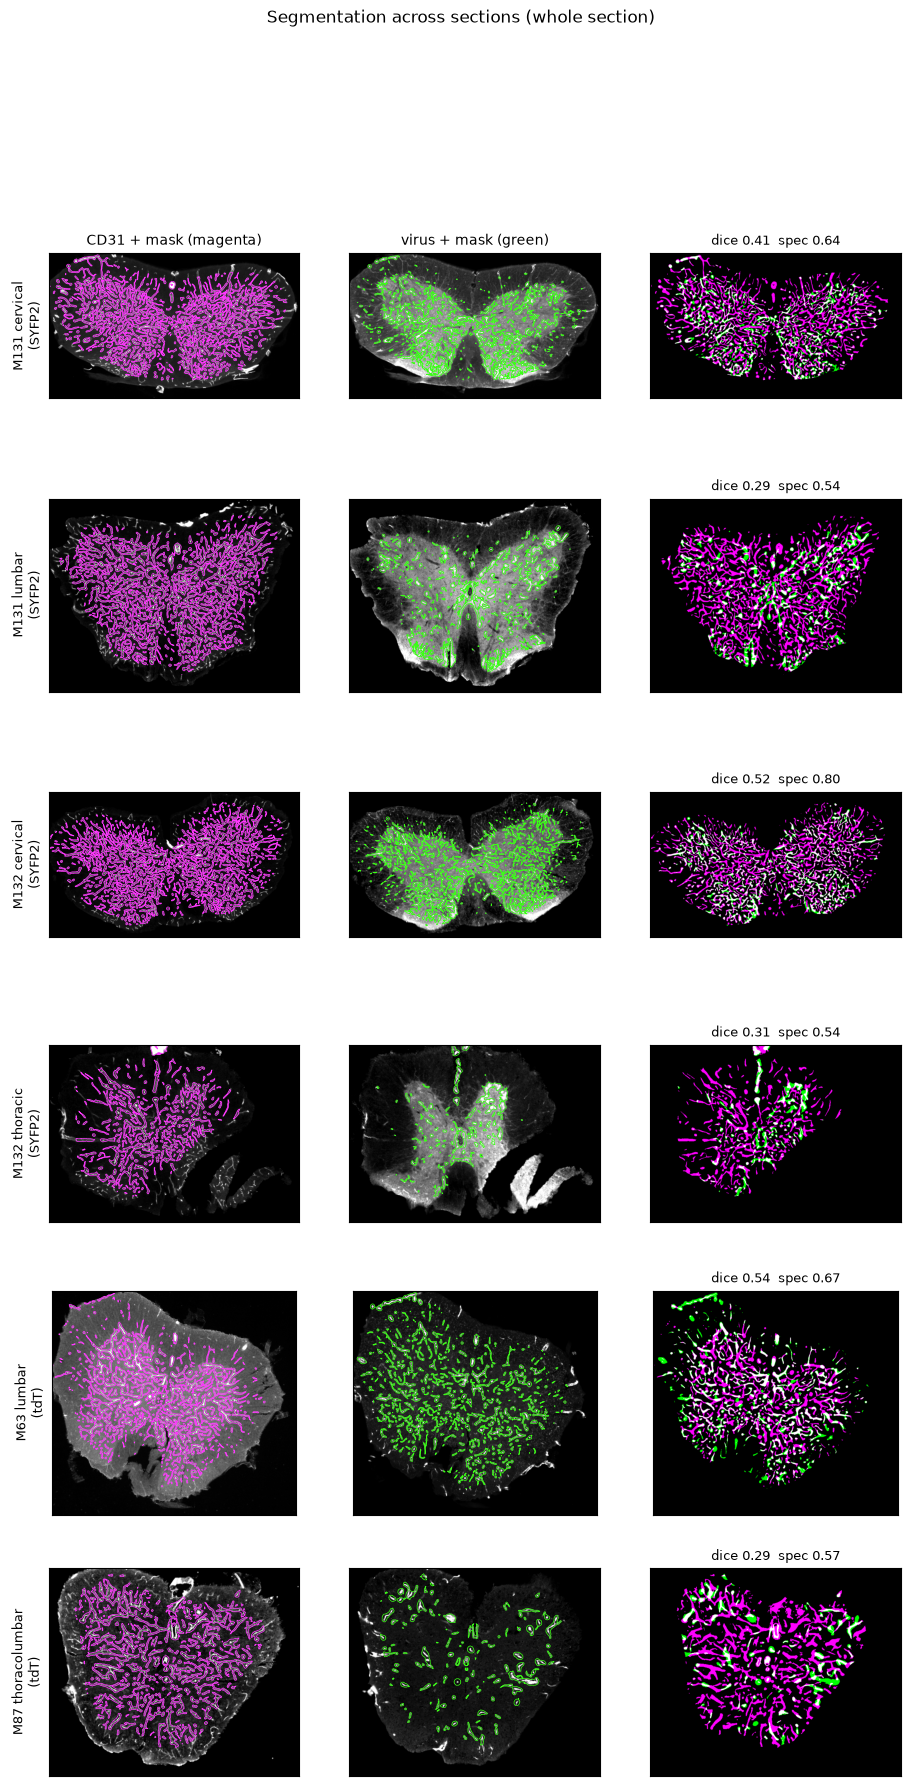

In [6]:
sel = np.unique(np.linspace(0, len(paths) - 1, min(6, len(paths))).astype(int))
gd = np.s_[::3, ::3]
fig, axes = plt.subplots(len(sel), 3, figsize=(11, 3.4 * len(sel)), squeeze=False)
for r, i in enumerate(sel):
    _, gmouse, gregion, grep, _ = NAME.match(paths[i].name).groups()
    grep = "SYFP2" if "SYFP2" in grep else ("tdT" if "tdT" in grep else grep)
    gv, gc, gt, gmv, gmc = channel_masks(paths[i])
    a0, a1, a2 = axes[r]
    a0.imshow(_clip(gc, gt)[gd], cmap="gray")
    if gmc[gd].any():
        a0.contour(gmc[gd].astype(float), [0.5], colors="#ff36ff", linewidths=0.5)
    a1.imshow(_clip(gv, gt)[gd], cmap="gray")
    if gmv[gd].any():
        a1.contour(gmv[gd].astype(float), [0.5], colors="#39ff14", linewidths=0.5)
    mv2, mc2 = gmv[gd], gmc[gd]
    ag = np.zeros((*mv2.shape, 3))
    ag[mv2 & mc2] = [1, 1, 1]; ag[mv2 & ~mc2] = [0, 1, 0]; ag[~mv2 & mc2] = [1, 0, 1]
    a2.imshow(ag)
    a0.set_ylabel(f"{gmouse} {REGION_NAME[gregion]}\n({grep})", fontsize=9)
    a2.set_title(f"dice {metrics.dice(gmv, gmc):.2f}  spec {metrics.precision(gmv, gmc):.2f}",
                 fontsize=9)
    if r == 0:
        a0.set_title("CD31 + mask (magenta)", fontsize=10)
        a1.set_title("virus + mask (green)", fontsize=10)
    for a in (a0, a1, a2):
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Segmentation across sections (whole section)")
plt.show()

## 800 µm close-up per section

The **same sections, zoomed in** — the ~800 µm densest-vessel close-up per section,
CD31 (magenta) and virus (green) mask contours and their agreement, so the masks
can be judged at native resolution. The full 800 µm crop set for every section is
in `results/zoom_panels/`.

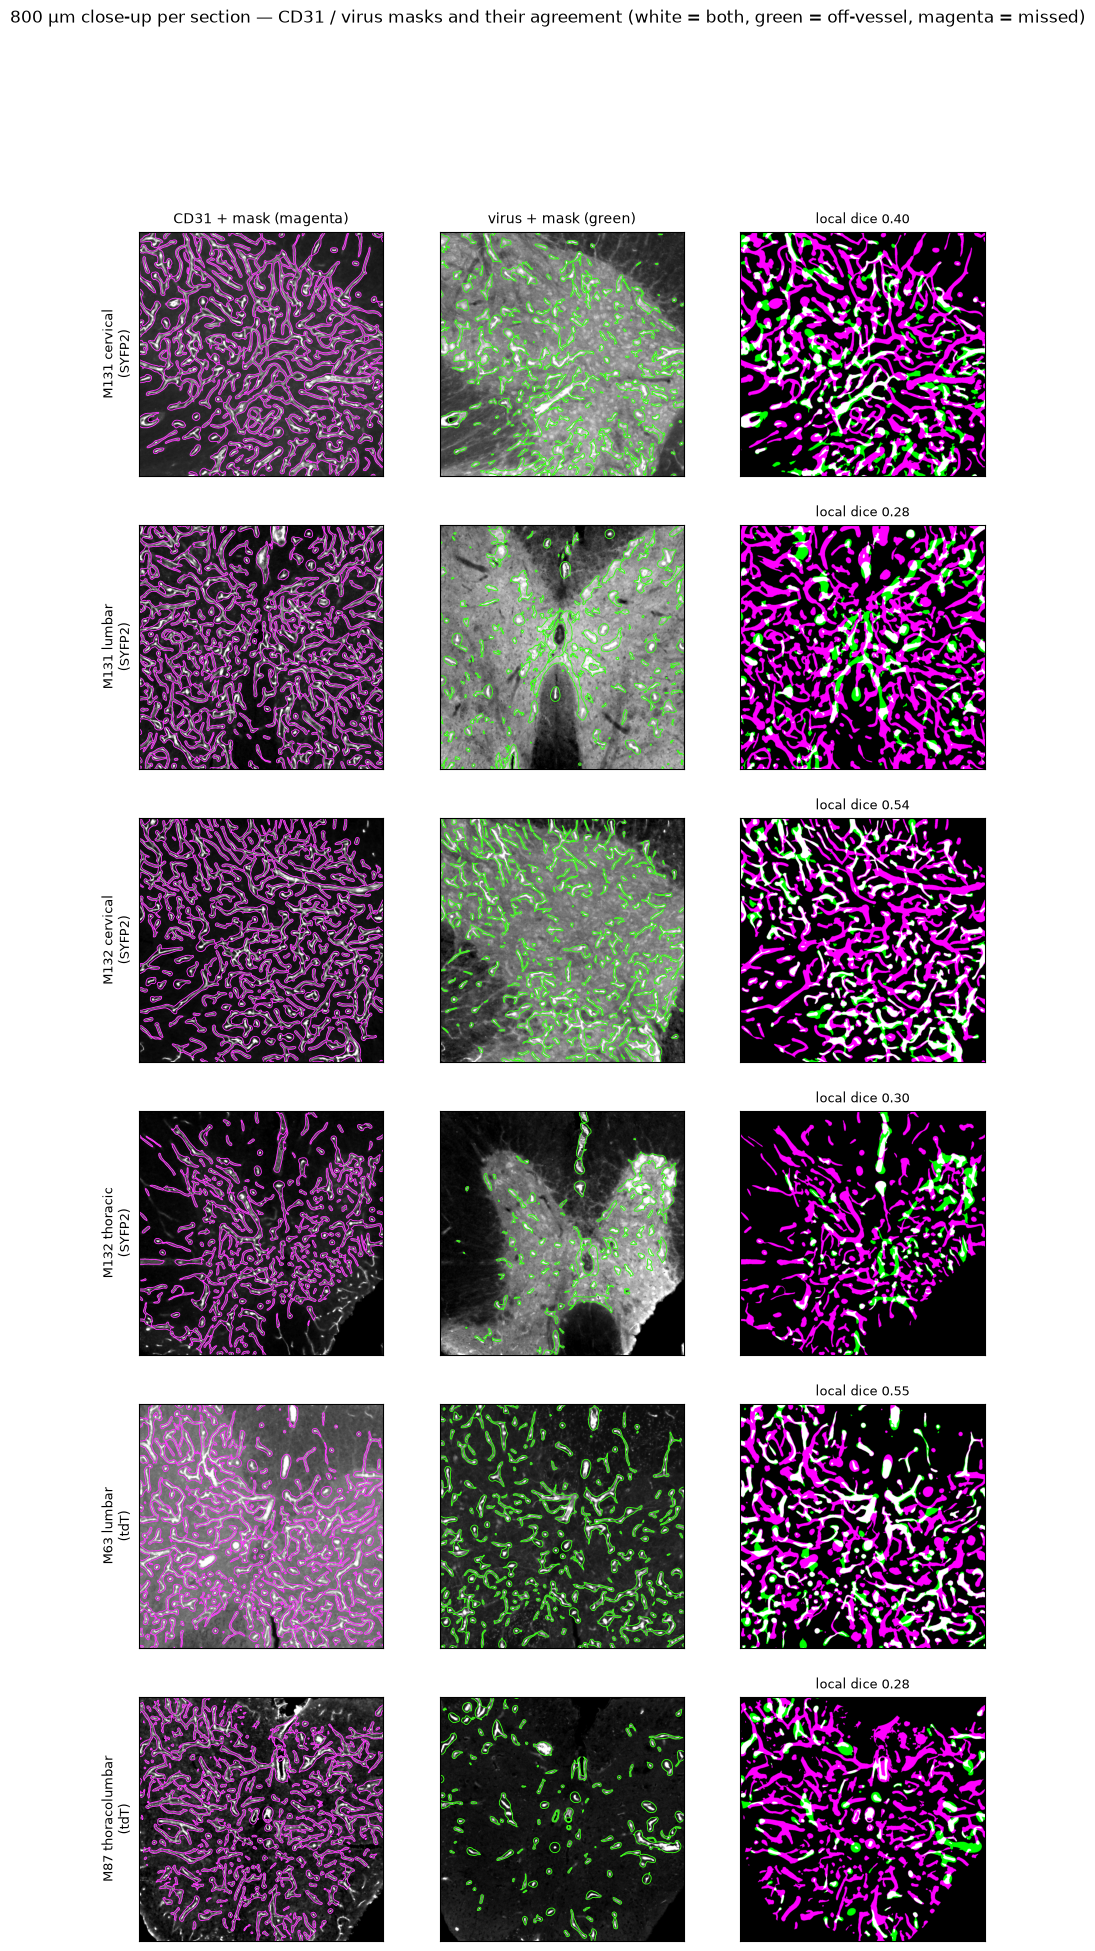

In [7]:
sel = np.unique(np.linspace(0, len(paths) - 1, min(6, len(paths))).astype(int))
half = CROP_PX // 2
box = lambda a: uniform_filter(a.astype(np.float32), size=CROP_PX, mode="constant")
fig, axes = plt.subplots(len(sel), 3, figsize=(11, 3.7 * len(sel)), squeeze=False)
for r, i in enumerate(sel):
    _, gmouse, gregion, grep, _ = NAME.match(paths[i].name).groups()
    grep = "SYFP2" if "SYFP2" in grep else ("tdT" if "tdT" in grep else grep)
    gv, gc, gt, gmv, gmc = channel_masks(paths[i])
    dense = top_q_mask(gc, gt, VIS_Q)
    H, W = gt.shape
    valid = np.zeros(gt.shape, bool)
    valid[half:H - half, half:W - half] = True
    valid &= box(gt.astype(np.float32)) > 0.6
    sl = (_crop_slice(np.unravel_index(
              np.argmax(np.where(valid, box(dense.astype(np.float32)), -np.inf)), gt.shape))
          if valid.any() else np.s_[::3, ::3])
    a0, a1, a2 = axes[r]
    a0.imshow(_clip(gc, gt)[sl], cmap="gray")
    if gmc[sl].any():
        a0.contour(gmc[sl].astype(float), [0.5], colors="#ff36ff", linewidths=0.6)
    a1.imshow(_clip(gv, gt)[sl], cmap="gray")
    if gmv[sl].any():
        a1.contour(gmv[sl].astype(float), [0.5], colors="#39ff14", linewidths=0.6)
    mvc, mcc = gmv[sl], gmc[sl]
    ag = np.zeros((*mvc.shape, 3))
    ag[mvc & mcc] = [1, 1, 1]; ag[mvc & ~mcc] = [0, 1, 0]; ag[~mvc & mcc] = [1, 0, 1]
    a2.imshow(ag)
    a0.set_ylabel(f"{gmouse} {REGION_NAME[gregion]}\n({grep})", fontsize=9)
    a2.set_title(f"local dice {metrics.dice(mvc, mcc):.2f}", fontsize=9)
    if r == 0:
        a0.set_title("CD31 + mask (magenta)", fontsize=10)
        a1.set_title("virus + mask (green)", fontsize=10)
    for a in (a0, a1, a2):
        a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"{CROP_UM:.0f} µm close-up per section — CD31 / virus masks and their "
             "agreement (white = both, green = off-vessel, magenta = missed)")
plt.show()

## Close-up — where the masks agree and disagree

Zoom into the densest-vessel window at **native resolution**. Left: the virus
channel with its own vessel-mask outline; middle: CD31 with its mask; right: the
agreement map (white = both, green = virus off a vessel, magenta = a vessel the
virus missed). The local Dice / specificity / coverage for this window are in the
title — a small patch, so they differ from the whole-section numbers above.

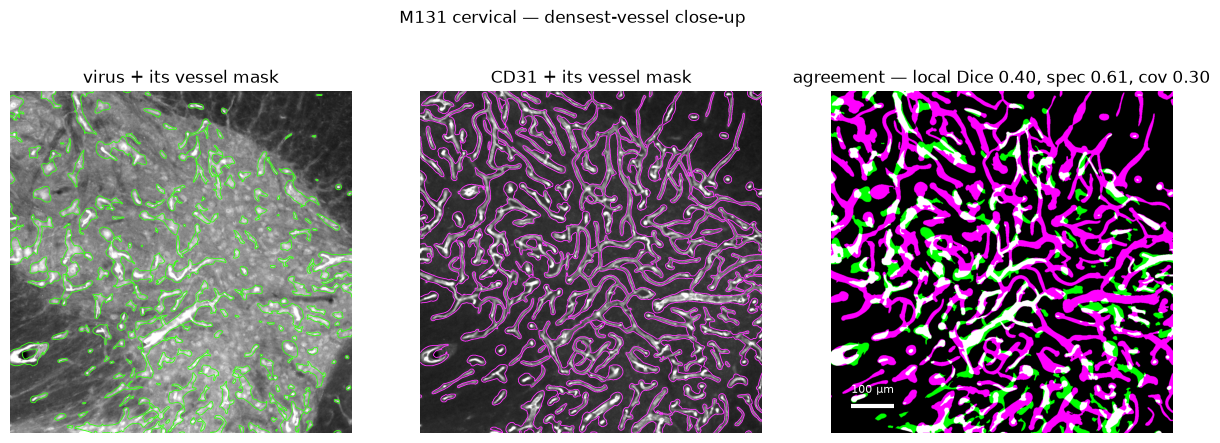

In [8]:
# Locate a ~500 um window with the most CD31 vessel area, then zoom in.
cd31_top = top_q_mask(cd31, tissue, VIS_Q)
box = lambda a: uniform_filter(a.astype(np.float32), size=CROP_PX, mode="constant")
half = CROP_PX // 2
rows_, cols_ = tissue.shape
valid = np.zeros(tissue.shape, bool)
valid[half:rows_ - half, half:cols_ - half] = True
valid &= box(tissue.astype(np.float32)) > 0.6
centre = np.unravel_index(
    np.argmax(np.where(valid, box(cd31_top.astype(np.float32)), -np.inf)), tissue.shape)
sl = _crop_slice(centre)

def clip(channel):
    lo, hi = np.percentile(channel[tissue], [1, 99])
    return np.clip((channel - lo) / max(hi - lo, 1e-6), 0, 1)

mv, mc = mask_virus[sl], mask_cd31[sl]
agree = np.zeros((*mv.shape, 3))
agree[mv & mc] = [1, 1, 1]; agree[mv & ~mc] = [0, 1, 0]; agree[~mv & mc] = [1, 0, 1]

fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
ax[0].imshow(clip(virus)[sl], cmap="gray")
ax[0].contour(mv.astype(float), [0.5], colors="#39ff14", linewidths=0.6)
ax[0].set_title("virus + its vessel mask")
ax[1].imshow(clip(cd31)[sl], cmap="gray")
ax[1].contour(mc.astype(float), [0.5], colors="#ff36ff", linewidths=0.6)
ax[1].set_title("CD31 + its vessel mask")
ax[2].imshow(agree); _add_scalebar(ax[2])
ax[2].set_title(f"agreement — local Dice {metrics.dice(mv, mc):.2f}, "
                f"spec {metrics.precision(mv, mc):.2f}, cov {metrics.recall(mv, mc):.2f}")
for a in ax:
    a.axis("off")
fig.suptitle(f"{mouse} {REGION_NAME[region]} — densest-vessel close-up")
plt.show()

## Comparison — high vs low specificity

The same agreement colouring for the window with the **highest** local specificity
(virus mask squarely on vessels) beside the one with the **lowest** (virus mask
spilling into parenchyma). This is what the specificity number means spatially.

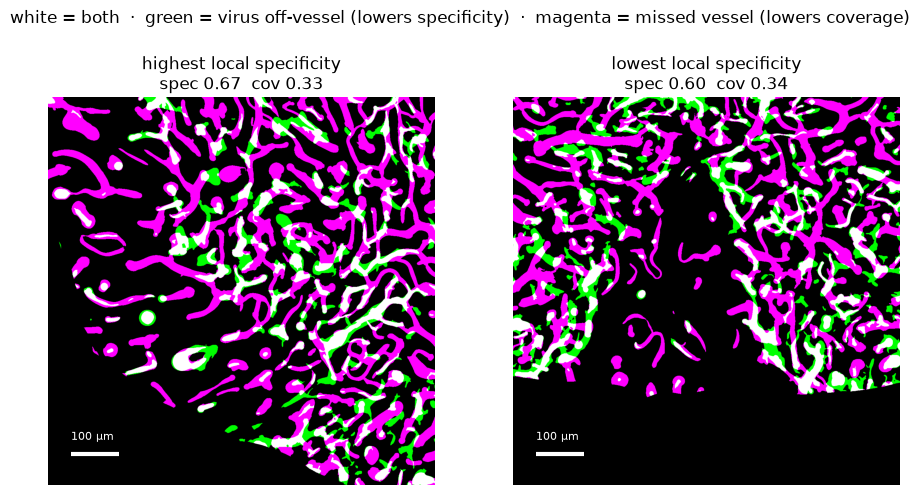

In [9]:
# Scan the section for where the virus mask sits most, and least, on CD31 vessels.
inter = box(mask_virus & mask_cd31)
vpos = box(mask_virus.astype(np.float32))
# Compare only windows with an above-median amount of virus mask, so the contrast
# is on- vs off-vessel *placement*, not virus density (a near-empty window would
# otherwise score high specificity trivially).
enough = valid & (vpos >= np.nanpercentile(vpos[valid], 50))
spec = np.where(enough, inter / (vpos + 1e-6), np.nan)
hi = np.unravel_index(np.nanargmax(spec), spec.shape)
lo = np.unravel_index(np.nanargmin(np.where(enough, spec, np.inf)), spec.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.8))
for a, centre_, name in [(ax[0], hi, "highest local specificity"),
                         (ax[1], lo, "lowest local specificity")]:
    s = _crop_slice(centre_)
    mvc, mcc = mask_virus[s], mask_cd31[s]
    ag = np.zeros((*mvc.shape, 3))
    ag[mvc & mcc] = [1, 1, 1]; ag[mvc & ~mcc] = [0, 1, 0]; ag[~mvc & mcc] = [1, 0, 1]
    a.imshow(ag); _add_scalebar(a); a.axis("off")
    a.set_title(f"{name}\nspec {metrics.precision(mvc, mcc):.2f}  "
                f"cov {metrics.recall(mvc, mcc):.2f}")
fig.suptitle("white = both  ·  green = virus off-vessel (lowers specificity)  ·  "
             "magenta = missed vessel (lowers coverage)")
plt.show()

## Segmentation methods on both channels — Jerman vs top-q%

The tuned Jerman masks scored above (cyan) beside the top-*q%* percentile masks
(amber), as contours on each raw channel so the grey-scale shows through. CD31
traces a clean vessel network with **either** method. The virus row is the point
of the whole comparison: **neither method traces vessels** — Jerman is sparse and
scattered, top-*q%* is dense neuronal blobs — because much of the bright virus is
genuinely non-vascular. (The same view for every section is exported by
`scripts/segmentation_contours.py`.)

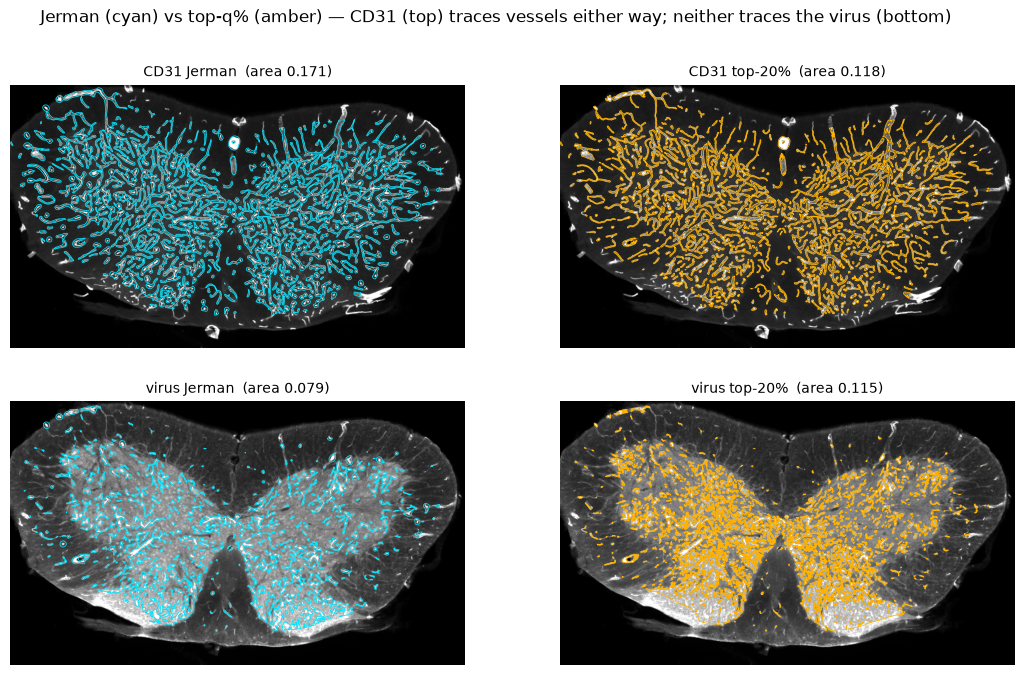

In [10]:
d = np.s_[::2, ::2]
h, w = cd31.shape
panels = [("CD31 Jerman", cd31, mask_cd31, "#00e5ff"),
          (f"CD31 top-{VIS_Q}%", cd31, top_q_mask(cd31, tissue, VIS_Q), "#ffb300"),
          ("virus Jerman", virus, mask_virus, "#00e5ff"),
          (f"virus top-{VIS_Q}%", virus, top_q_mask(virus, tissue, VIS_Q), "#ffb300")]
fig, axes = plt.subplots(2, 2, figsize=(13, 13 * h / w))
for (title, channel, mask, colour), ax in zip(panels, axes.ravel()):
    ax.imshow(_clip(channel, tissue)[d], cmap="gray")
    if mask[d].any():
        ax.contour(mask[d].astype(float), [0.5], colors=colour, linewidths=0.5)
    ax.set_title(f"{title}  (area {mask.mean():.3f})", fontsize=10)
    ax.axis("off")
fig.suptitle("Jerman (cyan) vs top-q% (amber) — CD31 (top) traces vessels either "
             "way; neither traces the virus (bottom)")
plt.show()

## Specificity and coverage by region

The directional pair, per region. With so few mice, read **direction-consistency
across animals**, not p-values.

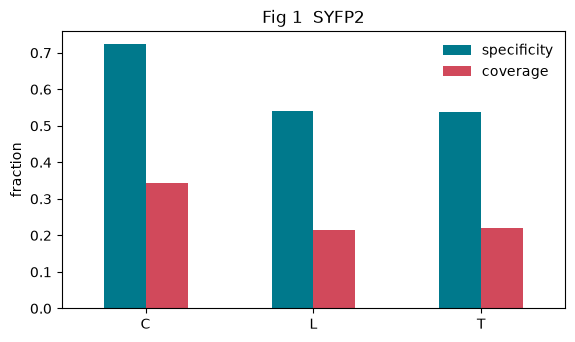

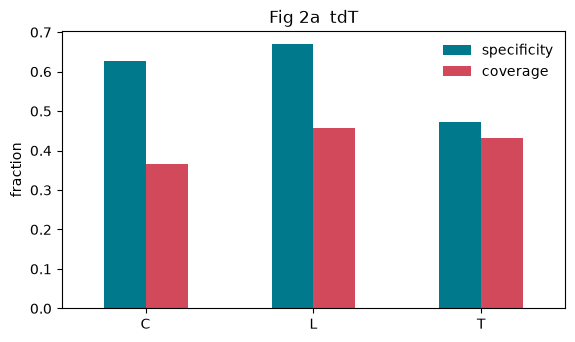

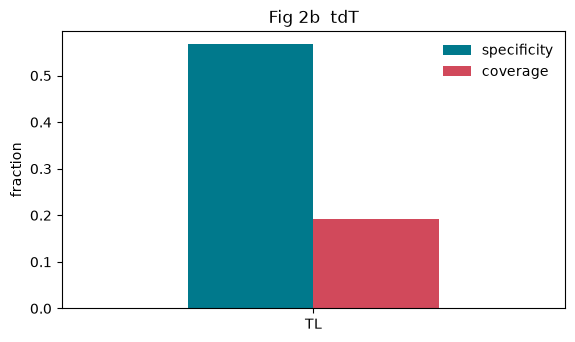

In [11]:
for (figure, reporter), block in summary.groupby(level=[0, 1]):
    block = block.droplevel([0, 1])
    ax = block[["specificity", "coverage"]].plot(kind="bar", figsize=(6.5, 3.6),
                                                 color=["#00798c", "#d1495b"], rot=0)
    ax.set_title(f"{figure}  {reporter}")
    ax.set_ylabel("fraction"); ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.show()

## Interpretation

- **Dice / Jaccard** summarise agreement in one symmetric number, but they blur two
  different failures together. **Specificity** and **coverage** separate them and
  are the interpretable pair.
- The virus cut is stricter than CD31's, so the virus mask keeps mostly its
  brightest, vessel-associated signal — that is why specificity here (~0.6) is far
  above the ~0.17 you get by segmenting the virus at CD31's own threshold. Pushing
  `VIRUS_HIGH` higher trades still-higher specificity for less coverage.
- **Even tuned, the virus mask cannot trace the CD31 network** — much of the virus
  is genuinely non-vascular. For the specificity claim, prefer the enrichment
  measure, which never segments the virus → see `enrichment_metrics.ipynb`.